In [14]:
# Cell 0: Setup project path so analysis_utils is recognized
from pathlib import Path
import sys, os

# Adjust if your path differs
PROJECT_ROOT = Path("/Users/acastano/Desktop/crispr_carT_AI_analysis").resolve()
PROJECT_ROOT = Path(
    os.environ.get(
        "CRISPR_CART_ROOT",
        "/Users/acastano/Desktop/crispr_carT_AI_analysis"
    )
).resolve()
# 1) Make Jupyter "stand" in the project root
os.chdir(PROJECT_ROOT)
print("CWD:", Path.cwd())

# 2) Make Python able to import your package
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Sanity checks
print("analysis_utils exists:", (PROJECT_ROOT / "analysis_utils").exists())
print("analysis_utils/__init__.py exists:", (PROJECT_ROOT / "analysis_utils" / "__init__.py").exists())


CWD: /Users/acastano/Desktop/crispr_carT_AI_analysis
analysis_utils exists: True
analysis_utils/__init__.py exists: True


In [15]:
# --- Cell 1: Imports & configuration ---

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from analysis_utils.config_utils import (
    PROCESSED_DIR,
    RESULTS_DIR,
    ensure_dirs,
)
from analysis_utils.umap_utils import compute_sample_umap, save_sample_umap

# Define UMAP results directory
UMAP_RESULTS_DIR = RESULTS_DIR / "umap"
ensure_dirs(UMAP_RESULTS_DIR)

PROCESSED_DIR, RESULTS_DIR, UMAP_RESULTS_DIR


(PosixPath('/Users/acastano/Desktop/crispr_carT_AI_analysis/data/processed'),
 PosixPath('/Users/acastano/Desktop/crispr_carT_AI_analysis/results'),
 PosixPath('/Users/acastano/Desktop/crispr_carT_AI_analysis/results/umap'))

In [16]:
# Cell 2: #1)Load original logCPM (ENSG) and metadata
expr_logcpm = pd.read_parquet(PROCESSED_DIR / "expr_logcpm.parquet")
metadata    = pd.read_csv(PROCESSED_DIR / "metadata_samples.csv", index_col=0)

# 2)Preserve ENSG version stripping (important!)
expr = expr_logcpm.copy()
expr.index = expr.index.str.split(".").str[0]

# 3) Load mapping ENSG -> symbol
mapping_df = pd.read_csv(PROCESSED_DIR / "ensg_to_symbol.csv")
ensg_to_symbol = dict(zip(mapping_df["ensembl"], mapping_df["symbol"]))


# 4) Build symbol-collapsed expression
expr = expr_logcpm.copy()
expr["symbol"] = expr.index.to_series().map(ensg_to_symbol)

expr_symbol = (
    expr
    .dropna(subset=["symbol"])
    .set_index("symbol")
    .groupby(level=0)
    .mean()
)

# Optional: save for future fast reuse

OUT_SYMBOL = PROCESSED_DIR / "expr_logcpm_symbol.parquet"
expr_symbol.to_parquet(OUT_SYMBOL)
print(f"Saved symbol-level expression → {OUT_SYMBOL}")
expr_symbol.shape, metadata.shape


Saved symbol-level expression → /Users/acastano/Desktop/crispr_carT_AI_analysis/data/processed/expr_logcpm_symbol.parquet


((41250, 60), (60, 6))

In [17]:
#Cell 2.1 – Load expression + metadata (symbol-level)

expr_symbol = pd.read_parquet(PROCESSED_DIR / "expr_logcpm_symbol.parquet")
metadata    = pd.read_csv(PROCESSED_DIR / "metadata_samples.csv", index_col=0)

assert expr_symbol.index.is_unique, "Gene symbols are not unique"
assert metadata.index.is_unique, "Metadata index is not unique"

expr_symbol.shape, metadata.shape
#“A05 operates on a cached, symbol-level expression matrix generated during preprocessing (A00), 
# ensuring consistent biological units across pathway analyses.”


((41250, 60), (60, 6))

In [18]:
# Cell 3 — Load Hallmark gene sets + define module scoring

import json
import numpy as np
import pandas as pd

# --- A) Load Hallmark gene sets (preferred: local JSON you version-control) ---
# This uses analysis_utils/config_utils.py paths if available; otherwise it falls back to a default.
try:
    from analysis_utils.config_utils import load_gene_sets, DEFAULT_GENE_SET_PATH
    gene_sets = load_gene_sets()  # loads from DEFAULT_GENE_SET_PATH
    print(f"Loaded gene sets from: {DEFAULT_GENE_SET_PATH}")
except Exception as e:
    print("Could not use analysis_utils.config_utils.load_gene_sets(). Falling back to local JSON.")
    # If you prefer an explicit path, change this:
    GENESET_JSON = PROCESSED_DIR.parent / "gene_sets" / "gene_sets.json"  # data/gene_sets/gene_sets.json
    with open(GENESET_JSON, "r") as f:
        gene_sets = json.load(f)
    print(f"Loaded gene sets from: {GENESET_JSON}")

print("Gene set categories:", list(gene_sets.keys())[:15], "...")
print("Total categories:", len(gene_sets))

# --- B) Define a robust module scoring function ---
def module_score(expr_symbols: pd.DataFrame, genes: list) -> pd.Series:
    """
    Compute a simple module score = mean expression across genes per sample.
    
    expr_symbols: DataFrame (genes(symbols) x samples)
    genes: list of gene symbols
    """
    genes_present = [g for g in genes if g in expr_symbols.index]
    if len(genes_present) == 0:
        # Return all-NaN if no overlap (keeps downstream code stable)
        return pd.Series(np.nan, index=expr_symbols.columns)
    return expr_symbols.loc[genes_present].mean(axis=0)

# --- C) Pick Hallmark pathways of interest (edit if you want) ---
pathways_of_interest = [
    "IL-2/STAT5 Signaling",
    "TNF-alpha Signaling via NF-kB",
    "Interferon Alpha Response",
    "Interferon Gamma Response",
    "Inflammatory Response",
    "Apoptosis",
    "E2F Targets",
    "G2M Checkpoint",
    "Oxidative Phosphorylation",
]

# Keep only those that exist in your gene_sets file
missing = [p for p in pathways_of_interest if p not in gene_sets]
if missing:
    print("⚠️ Missing from gene_sets JSON (will be skipped):", missing)

pathways_of_interest = [p for p in pathways_of_interest if p in gene_sets]
print("Using pathways:", pathways_of_interest)

# --- D) Compute module scores (per sample) ---
scores = {}
overlap_report = []

for pw in pathways_of_interest:
    genes = gene_sets[pw]
    s = module_score(expr_symbol, genes)
    scores[pw] = s
    
    # overlap stats
    n_in_set = len(genes)
    n_present = sum([g in expr_symbol.index for g in genes])
    overlap_report.append((pw, n_present, n_in_set, n_present / max(n_in_set, 1)))

scores_df = pd.DataFrame(scores)  # rows = samples, cols = pathways
scores_df.index.name = "sample_id"

overlap_df = pd.DataFrame(
    overlap_report,
    columns=["Pathway", "n_genes_present", "n_genes_total", "fraction_present"]
).sort_values("fraction_present", ascending=False)

display(scores_df.head())
display(overlap_df)

Loaded gene sets from: /Users/acastano/Desktop/crispr_carT_AI_analysis/data/gene_sets/gene_sets.json
Gene set categories: ['effector_cytotoxic', 'activation_early', 'exhaustion_checkpoint', 'regulatory_stress', 'migration_cytoskeleton', 'proliferation_cellcycle', 'memory_homeostasis', 'metabolic_programs'] ...
Total categories: 8
⚠️ Missing from gene_sets JSON (will be skipped): ['IL-2/STAT5 Signaling', 'TNF-alpha Signaling via NF-kB', 'Interferon Alpha Response', 'Interferon Gamma Response', 'Inflammatory Response', 'Apoptosis', 'E2F Targets', 'G2M Checkpoint', 'Oxidative Phosphorylation']
Using pathways: []


""
sample_id


,Pathway,n_genes_present,n_genes_total,fraction_present


In [19]:
import numpy as np
import pandas as pd
from scipy.stats import zscore

# -----------------------------
# A05 — Build Hallmark heatmap
# -----------------------------

# Defensive: remove any previous broken hm
for v in ["hm", "hm_z"]:
    if v in globals():
        del globals()[v]

# Pathway order (rows)
row_order = [
    "IL-2/STAT5 Signaling",
    "Inflammatory Response",
    "Interferon Alpha Response",
    "Interferon Gamma Response",
    "Apoptosis",
    "E2F Targets",
    "Oxidative Phosphorylation",
]

# meta_scores must be: samples × pathways
assert isinstance(meta_scores, pd.DataFrame), "meta_scores must be a DataFrame"

keep = [r for r in row_order if r in meta_scores.columns]

# Build heatmap matrix: pathways × samples
hm = meta_scores.loc[:, keep].T.copy()

# Z-score each pathway across samples
hm = pd.DataFrame(
    zscore(hm.to_numpy(), axis=1, nan_policy="omit"),
    index=hm.index,
    columns=hm.columns
)

# Ensure consistent ordering
hm = hm.reindex(keep)

print("hm shape (pathways × samples):", hm.shape)
print("hm is DataFrame:", isinstance(hm, pd.DataFrame))

NameError: name 'meta_scores' is not defined

In [20]:
metadata.index = metadata.index.astype(str)
hm.columns = hm.columns.astype(str)

col_meta = metadata.loc[hm.columns, ["guide", "hours"]].copy()
col_labels = [f"{g}_{int(h)}h" for g, h in zip(col_meta["guide"], col_meta["hours"])]

NameError: name 'hm' is not defined

In [21]:
# Cell 4  — Define pathsfrom pathlib import Path

RESULTS_DIR = PROJECT_ROOT / "results"
PCA_RESULTS_DIR = RESULTS_DIR / "pca"
PATHWAYS_RESULTS_DIR = RESULTS_DIR / "pathways"

PATHWAYS_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

PCA_RESULTS_DIR

PosixPath('/Users/acastano/Desktop/crispr_carT_AI_analysis/results/pca')

In [22]:
#Cell 5 — Compute Hallmark module scores (this fixes the 60 missing rows)
import gseapy as gp
import pandas as pd
import numpy as np

# Load Hallmark gene sets
hallmark_sets = gp.get_library("MSigDB_Hallmark_2020")

# Pathways you decided to keep (publication set)
pathways_of_interest = [
    "IL-2/STAT5 Signaling",
    "Interferon Alpha Response",
    "Interferon Gamma Response",
    "Inflammatory Response",
    "Apoptosis",
    "E2F Targets",
    "Oxidative Phosphorylation",
]

# Helper: module score = mean expression of pathway genes
def module_score(expr_df, gene_list):
    genes = [g for g in gene_list if g in expr_df.index]
    if len(genes) == 0:
        return pd.Series(np.nan, index=expr_df.columns)
    return expr_df.loc[genes].mean(axis=0)

# Compute scores per pathway
module_scores = {}

for pw in pathways_of_interest:
    gene_list = hallmark_sets[pw]
    module_scores[pw] = module_score(expr_symbol, gene_list)

scores_df = pd.DataFrame(module_scores)
scores_df.index.name = "sample_id"

scores_df.shape

(60, 7)

In [23]:
# Cell 6 — Join module scores + PCA scores to metadata
# Join module scores
meta_scores = metadata.join(scores_df, how="left")

print("After module join:", meta_scores.shape)
print("Missing rows:", meta_scores[pathways_of_interest].isna().all(axis=1).sum())

After module join: (60, 13)
Missing rows: 0


In [24]:
# Cell 7 — Attach PC1 / PC2 (robust, explicit)
# Load PCA scores from A01
pca_scores_path = PCA_RESULTS_DIR / "pca_scores.parquet"
assert pca_scores_path.exists(), "Run A01 first — PCA scores not found."

pcs_df = pd.read_parquet(pca_scores_path)[["PC1", "PC2"]]

meta_scores = meta_scores.join(pcs_df, how="left")

assert {"PC1", "PC2"}.issubset(meta_scores.columns)
meta_scores.head()

,GSM,title,cell_type,hours,guide,donor,IL-2/STAT5 Signaling,Interferon Alpha Response,Interferon Gamma Response,Inflammatory Response,Apoptosis,E2F Targets,Oxidative Phosphorylation,PC1,PC2
sample_id,,,,,,,,,,,,,,,
CART0077_RNAseq_NgsRun1_001,"""GSM8252546""","""CD4, 0h, SafeHarbor, CART0077_D1""",CD4,0,SafeHarbor,CART0077_D1,3.287308,3.808795,3.608408,2.247535,3.417555,4.397543,4.021530,-36.608980,-31.024521
CART0077_RNAseq_NgsRun1_002,"""GSM8252547""","""CD4, 0h, RHOG, CART0077_D1""",CD4,0,RHOG,CART0077_D1,3.245423,3.787795,3.578101,2.219672,3.406910,4.333981,4.002538,-38.726879,-31.195909
CART0077_RNAseq_NgsRun1_003,"""GSM8252548""","""CD4, 0h, SafeHarbor, CART0077_D2""",CD4,0,SafeHarbor,CART0077_D2,3.340002,3.845678,3.676700,2.298057,3.414869,4.508214,4.065113,-30.944237,-29.247542
CART0077_RNAseq_NgsRun1_004,"""GSM8252549""","""CD4, 0h, RHOG, CART0077_D2""",CD4,0,RHOG,CART0077_D2,3.241723,3.830734,3.615120,2.233861,3.397448,4.347819,4.007366,-39.028631,-31.262182
CART0077_RNAseq_NgsRun1_005,"""GSM8252550""","""CD4, 0h, SafeHarbor, CART0077_D3""",CD4,0,SafeHarbor,CART0077_D3,3.165271,3.878053,3.605778,2.187870,3.366691,4.298775,4.028794,-39.389334,-32.215399


In [25]:
#Cell 8 — Hallmark ↔ PCA correlations (the actual science)
corr_rows = []

for pw in pathways_of_interest:
    s = meta_scores[pw].astype(float)
    corr_rows.append({
        "Pathway": pw,
        "corr_PC1": meta_scores["PC1"].corr(s),
        "corr_PC2": meta_scores["PC2"].corr(s),
    })

corr_df = (
    pd.DataFrame(corr_rows)
    .set_index("Pathway")
    .loc[pathways_of_interest]
)

corr_df

,corr_PC1,corr_PC2
Pathway,,
IL-2/STAT5 Signaling,0.949222,-0.021961
Interferon Alpha Response,-0.487390,-0.647592
Interferon Gamma Response,-0.148222,-0.549863
Inflammatory Response,0.958999,-0.094939
Apoptosis,0.891660,0.130125
E2F Targets,0.681968,0.035590
Oxidative Phosphorylation,0.833682,0.194009


In [26]:
# Cell 9 — Save publication-ready outputs
meta_scores.to_csv(PATHWAYS_RESULTS_DIR / "metadata_with_hallmark_scores.csv")
corr_df.to_csv(PATHWAYS_RESULTS_DIR / "hallmark_pc_correlations_PC1_PC2.csv")

print("Saved:")
print(" - metadata_with_hallmark_scores.csv")
print(" - hallmark_pc_correlations_PC1_PC2.csv")

Saved:
 - metadata_with_hallmark_scores.csv
 - hallmark_pc_correlations_PC1_PC2.csv


In [27]:
# Cell 10 — Order samples (time → guide)
#Which biological programs define PC1/PC2 and how do they evolve over time and perturbation?
# Order samples by activation time, then guide
meta_scores["hours"] = meta_scores["hours"].astype(float)

sample_order = (
    meta_scores
    .sort_values(["guide", "hours"])
    .index
)

sample_order[:10]

Index(['CART0077_RNAseq_NgsRun1_002', 'CART0077_RNAseq_NgsRun1_004',
       'CART0077_RNAseq_NgsRun1_006', 'CART0077_RNAseq_NgsRun1_008',
       'CART0077_RNAseq_NgsRun1_010', 'CART0077_RNAseq_NgsRun1_012',
       'CART0077_RNAseq_NgsRun1_014', 'CART0077_RNAseq_NgsRun1_016',
       'CART0077_RNAseq_NgsRun1_018', 'CART0077_RNAseq_NgsRun1_020'],
      dtype='object', name='sample_id')

In [28]:
# Cell 11 — Build Hallmark matrix
import seaborn as sns
import matplotlib.pyplot as plt

heatmap_df = (
    meta_scores
    .loc[sample_order, pathways_of_interest]
    .astype(float)
)

heatmap_df.shape

(60, 7)

In [29]:
# Cell 12 — Z-score across samples (recommended)
heatmap_z = (heatmap_df - heatmap_df.mean()) / heatmap_df.std()

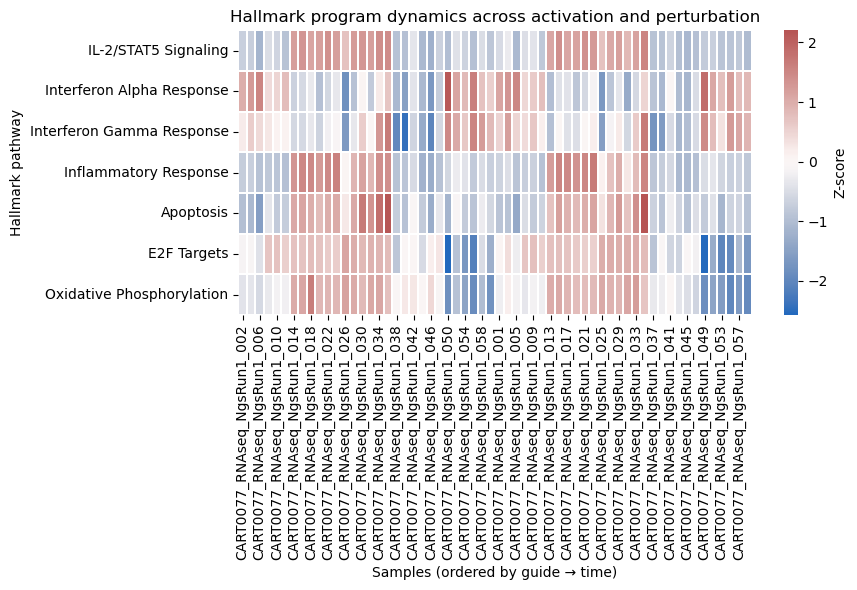

In [30]:
# Cell 13 — Final Hallmark heatmap (Panel D3)
plt.figure(figsize=(9, 6))

sns.heatmap(
    heatmap_z.T,
    cmap="vlag",
    center=0,
    cbar_kws={"label": "Z-score"},
    linewidths=0.3
)

plt.xlabel("Samples (ordered by guide → time)")
plt.ylabel("Hallmark pathway")
plt.title("Hallmark program dynamics across activation and perturbation")

plt.tight_layout()
plt.savefig(
    PATHWAYS_RESULTS_DIR / "hallmark_module_heatmap_A05.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

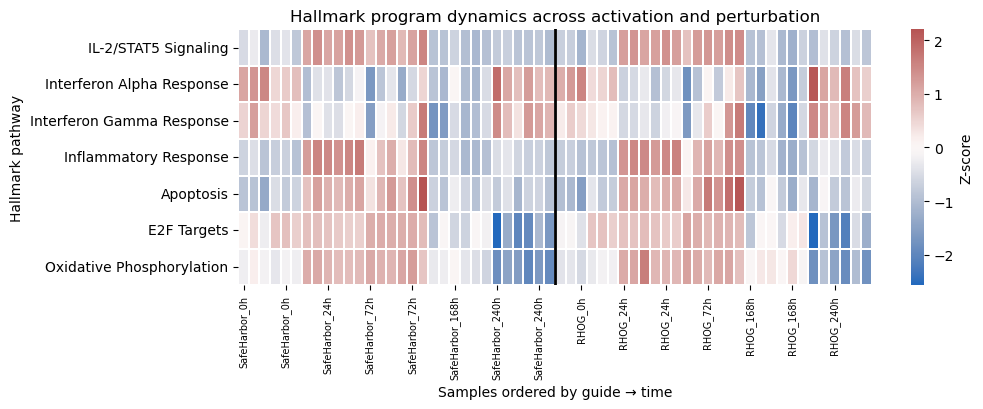

PosixPath('/Users/acastano/Desktop/crispr_carT_AI_analysis/results/pathways/Fig_D3_hallmark_module_heatmap_by_guide_time.png')

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1) Order samples by guide then time ---
meta_scores = meta_scores.copy()
meta_scores["hours"] = meta_scores["hours"].astype(float)

# Ensure guide order (SafeHarbor first, then RHOG)
guide_order = ["SafeHarbor", "RHOG"]
meta_scores["guide"] = pd.Categorical(meta_scores["guide"], categories=guide_order, ordered=True)

meta_scores_sorted = meta_scores.sort_values(["guide", "hours"])
sample_order = meta_scores_sorted.index.tolist()

# --- 2) Build matrix (samples x pathways) and z-score across samples ---
heatmap_df = meta_scores_sorted.loc[sample_order, pathways_of_interest].astype(float)
heatmap_z = (heatmap_df - heatmap_df.mean(axis=0)) / heatmap_df.std(axis=0)

# --- 3) Create a compact x-label: guide + hours (instead of full sample ID) ---
x_labels = [f"{g}_{int(h)}h" for g, h in zip(meta_scores_sorted["guide"], meta_scores_sorted["hours"])]

# --- 4) Find where the guide switches (for a separator) ---
guide_series = meta_scores_sorted["guide"].astype(str).values
switch_idx = np.where(guide_series[:-1] != guide_series[1:])[0]
split_pos = int(switch_idx[0] + 1) if len(switch_idx) > 0 else None

# --- 5) Plot ---
plt.figure(figsize=(10.5, 4.2))
ax = sns.heatmap(
    heatmap_z.T,
    cmap="vlag",
    center=0,
    cbar_kws={"label": "Z-score"},
    linewidths=0.25,
    xticklabels=False,   # hide: too dense
    yticklabels=True
)

# Add separator between guides
if split_pos is not None:
    ax.axvline(split_pos, color="black", linewidth=2)

# Optional: show sparse x labels (every 4th)
step = 4
ax.set_xticks(np.arange(0, len(x_labels), step) + 0.5)
ax.set_xticklabels([x_labels[i] for i in range(0, len(x_labels), step)], rotation=90, fontsize=7)

ax.set_xlabel("Samples ordered by guide → time")
ax.set_ylabel("Hallmark pathway")
ax.set_title("Hallmark program dynamics across activation and perturbation")

plt.tight_layout()

outpath = PATHWAYS_RESULTS_DIR / "Fig_D3_hallmark_module_heatmap_by_guide_time.png"
plt.savefig(outpath, dpi=300, bbox_inches="tight")
plt.show()

outpath

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Guard rails
# -----------------------------
if isinstance(hm, pd.Series):
    raise TypeError(
        "hm is a Series (was overwritten). Re-run the cell that builds hm as a DataFrame "
        "(pathways × samples)."
    )
if not isinstance(hm, pd.DataFrame):
    raise TypeError(f"hm must be a DataFrame, got: {type(hm)}")

# Ensure consistent string indexing
metadata = metadata.copy()
metadata.index = metadata.index.astype(str)

hm_plot = hm.copy()
hm_plot.columns = hm_plot.columns.astype(str)

# Optional: enforce row order
row_order = [
    "IL-2/STAT5 Signaling",
    "Inflammatory Response",
    "Interferon Gamma Response",
    "Interferon Alpha Response",
    "Apoptosis",
    "E2F Targets",
    "Oxidative Phosphorylation",
]
hm_plot = hm_plot.reindex([r for r in row_order if r in hm_plot.index])

# -----------------------------
# Build x-axis labels from metadata (S/R + time)
# -----------------------------
col_meta = metadata.loc[hm_plot.columns, ["guide", "hours"]].copy()

short_labels = [
    f"{'S' if g == 'SafeHarbor' else 'R'}:{int(h)}h"
    for g, h in zip(col_meta["guide"], col_meta["hours"])
]

# show fewer tick labels (every Nth), prevents label pile-up
N = 3  # try 2 or 4 if you want denser/sparser
tick_positions = np.arange(len(short_labels))[::N]
tick_labels = [short_labels[i] for i in tick_positions]

# time-block boundaries + top axis
time_vals = col_meta["hours"].to_numpy()
boundaries = np.where(time_vals[:-1] != time_vals[1:])[0]

time_groups = col_meta.groupby("hours", sort=True).indices
time_centers = [np.mean(idxs) for _, idxs in time_groups.items()]
time_labels = [f"{int(t)} h" for t in time_groups.keys()]

# --- plot ---
fig, ax = plt.subplots(figsize=(12, 4))

im = ax.imshow(hm_plot.values, aspect="auto", interpolation="nearest", vmin=-2, vmax=2)

ax.set_yticks(np.arange(hm_plot.shape[0]))
ax.set_yticklabels(hm_plot.index, fontsize=9)

ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels, rotation=90, fontsize=9)

for b in boundaries:
    ax.axvline(b + 0.5, color="k", linewidth=0.6, alpha=0.35)

# top axis = time only
ax2 = ax.twiny()
ax2.set_xlim(ax.get_xlim())
ax2.set_xticks(time_centers)
ax2.set_xticklabels(time_labels, fontsize=9)
ax2.set_xlabel("Activation time", fontsize=11)

ax.set_title("Hallmark program dynamics across activation and perturbation")
ax.set_xlabel("Samples ordered by time (within each time: S/R replicates)")
ax.set_ylabel("Hallmark pathway")

# move the S/R note so it doesn't collide with tick labels
ax.text(
    0.1, -0.25,
    "S = SafeHarbor   |   R = RHOG",
    ha="center", va="top",
    fontsize=8,
    transform=ax.transAxes,
)

# put colorbar OUTSIDE (no overlap)
# Create a new axis for the colorbar (manual placement)
cax = fig.add_axes([0.945, 0.35, 0.012, 0.53])
#                [left, bottom, width, height]

cbar = fig.colorbar(im, cax=cax)
cbar.set_label("Z-score", fontsize=8
            )
# extra bottom margin for rotated ticks + note

fig.subplots_adjust(left=0.26)
# layout fixes for publication
fig.subplots_adjust(
    left=0.25,   # room for pathway names + y-label
    right=0.93,  # room for colorbar
    bottom=0.35, # rotated x labels + S/R note
    top=0.88     # title + top time axis
)
fig.subplots_adjust(
    left=0.25,
    right=0.92,   # leave space for colorbar
    bottom=0.35,
    top=0.88
)

plt.show()

fig, ax = plt.subplots(figsize=(8, 6))


# plotting code here
# ax.scatter(...)
# ax.imshow(...)
# etc.

outpath = PATHWAYS_RESULTS_DIR / "Fig_D3_hallmark_module_heatmap A05_by_guide_time.png"
plt.savefig(outpath, dpi=300, bbox_inches="tight")
plt.show()

plt.tight_layout()


print(f"Saved: {out_path}")



NameError: name 'hm' is not defined

In [33]:
metadata.groupby(["guide", "hours"]).size()


guide       hours
RHOG        0        6
            24       6
            72       6
            168      6
            240      6
SafeHarbor  0        6
            24       6
            72       6
            168      6
            240      6
dtype: int64

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Guard rails
# -----------------------------
if isinstance(hm, pd.Series):
    raise TypeError(
        "hm is a Series (was overwritten). Re-run the cell that builds hm as a DataFrame "
        "(pathways × samples)."
    )
if not isinstance(hm, pd.DataFrame):
    raise TypeError(f"hm must be a DataFrame, got: {type(hm)}")

# Ensure consistent string indexing
metadata = metadata.copy()
metadata.index = metadata.index.astype(str)

hm_plot = hm.copy()
hm_plot.columns = hm_plot.columns.astype(str)

# Optional: enforce row order
row_order = [
    "IL-2/STAT5 Signaling",
    "Inflammatory Response",
    "Interferon Gamma Response",
    "Interferon Alpha Response",
    "Apoptosis",
    "E2F Targets",
    "Oxidative Phosphorylation",
]
hm_plot = hm_plot.reindex([r for r in row_order if r in hm_plot.index])

# -----------------------------
# Build x-axis labels from metadata (S/R + time)
# -----------------------------

col_meta = metadata.loc[hm_plot.columns, ["guide", "hours"]].copy()

short_labels = [
    f"{'S' if g == 'SafeHarbor' else 'R'}:{int(h)}h"
    for g, h in zip(col_meta["guide"], col_meta["hours"])
]

# show fewer tick labels (every Nth), prevents label pile-up
N = 3  # try 2 or 4 if you want denser/sparser
tick_positions = np.arange(len(short_labels))[::N]
tick_labels = [short_labels[i] for i in tick_positions]

# time-block boundaries + top axis
time_vals = col_meta["hours"].to_numpy()
boundaries = np.where(time_vals[:-1] != time_vals[1:])[0]

time_groups = col_meta.groupby("hours", sort=True).indices
time_centers = [np.mean(idxs) for _, idxs in time_groups.items()]
time_labels = [f"{int(t)} h" for t in time_groups.keys()]

# --- plot ---
fig, ax = plt.subplots(figsize=(12, 4))

im = ax.imshow(hm_plot.values, aspect="auto", interpolation="nearest", vmin=-2, vmax=2)

ax.set_yticks(np.arange(hm_plot.shape[0]))
ax.set_yticklabels(hm_plot.index, fontsize=9)

ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels, rotation=90, fontsize=9)

for b in boundaries:
    ax.axvline(b + 0.5, color="k", linewidth=0.6, alpha=0.35)

# top axis = time only
ax2 = ax.twiny()
ax2.set_xlim(ax.get_xlim())
ax2.set_xticks(time_centers)
ax2.set_xticklabels(time_labels, fontsize=9)
ax2.set_xlabel("Activation time", fontsize=11)

ax.set_title("Hallmark program dynamics across activation and perturbation")
ax.set_xlabel("Samples ordered by time (within each time: S/R replicates)")
ax.set_ylabel("Hallmark pathway")

# move the S/R note so it doesn't collide with tick labels
ax.text(
    0.1, -0.25,
    "S = SafeHarbor   |   R = RHOG",
    ha="center", va="top",
    fontsize=8,
    transform=ax.transAxes,
)

# put colorbar OUTSIDE (no overlap)
# Create a new axis for the colorbar (manual placement)
cax = fig.add_axes([0.945, 0.35, 0.012, 0.53])
#                [left, bottom, width, height]

cbar = fig.colorbar(im, cax=cax)
cbar.set_label("Z-score", fontsize=8
            )
# extra bottom margin for rotated ticks + note

fig.subplots_adjust(left=0.26)

# layout fixes for publication
fig.subplots_adjust(
    left=0.25,   # room for pathway names + y-label
    right=0.93,  # room for colorbar
    bottom=0.35, # rotated x labels + S/R note
    top=0.88     # title + top time axis
)
fig.subplots_adjust(
    left=0.25,
    right=0.92,   # leave space for colorbar
    bottom=0.35,
    top=0.88
)

plt.show()

fig, ax = plt.subplots(figsize=(8, 6))

# -----------------------------
# Save figure (publication quality)
# -----------------------------
fig.tight_layout(rect=[0, 0.15, 1, 1])

# ✅ SAVE *THIS* FIGURE
fig.savefig(
    "results/pathways/FigD2_hallmark_module_heatmap_by_guide_time.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()
plt.close(fig)

NameError: name 'hm' is not defined

NameError: name 'hm_plot' is not defined

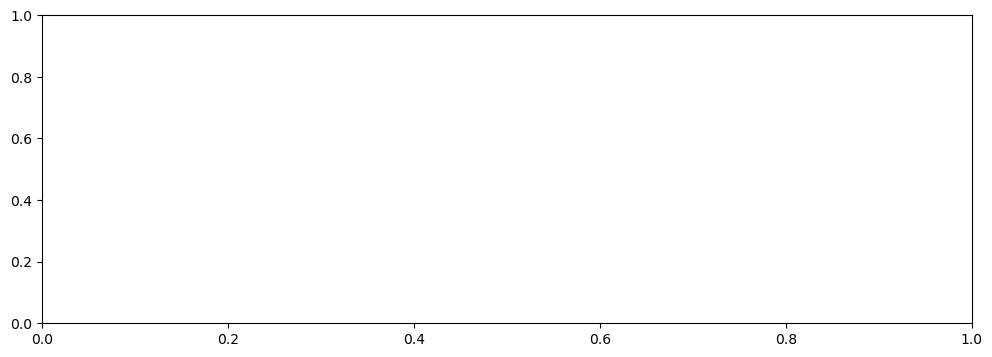

In [35]:
fig, ax = plt.subplots(figsize=(12, 4))

im = ax.imshow(
    hm_plot.values,
    aspect="auto",
    interpolation="nearest",
    vmin=-2,
    vmax=2
)

ax.set_yticks(range(hm_plot.shape[0]))
ax.set_yticklabels(hm_plot.index, fontsize=10)

ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels, rotation=90, fontsize=9)

ax.set_title("Hallmark program dynamics across activation and perturbation")
ax.set_xlabel("Samples ordered by time (within each time: S/R replicates)")
ax.set_ylabel("Hallmark pathway")

cbar = fig.colorbar(im, ax=ax, fraction=0.025, pad=0.04)
cbar.set_label("Z-score")

ax.text(
    0.5, -0.28,
    "S = SafeHarbor   |   R = RHOG",
    ha="center", va="top",
    fontsize=10,
    transform=ax.transAxes,
)

fig.tight_layout(rect=[0, 0.15, 1, 1])

# ✅ SAVE *THIS* FIGURE
fig.savefig(
    "results/pathways/FigD2_hallmark_module_heatmap_by_guide_time.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()
plt.close(fig)

In [36]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

# --- Required inputs ---
# hm_plot: DataFrame (rows = pathways, cols = samples) already z-scored
# col_meta: DataFrame indexed by hm_plot.columns with columns ["guide","hours"]
# Example:
# col_meta = metadata.loc[hm_plot.columns, ["guide","hours"]].copy()

# -----------------------------
# Safety checks
# -----------------------------
if isinstance(hm_plot, pd.Series):
    raise TypeError("hm_plot is a Series; expected a DataFrame. Rebuild hm_plot as pathways × samples.")

if not isinstance(hm_plot, pd.DataFrame):
    raise TypeError(f"hm_plot must be a DataFrame, got {type(hm_plot)}")

# Ensure alignment types
col_meta = col_meta.copy()
col_meta.index = col_meta.index.astype(str)
hm_plot.columns = hm_plot.columns.astype(str)

# -----------------------------
# Build bottom labels (S/R + hour per replicate)
# -----------------------------
sr = np.where(col_meta["guide"].values == "SafeHarbor", "S", "R")
hrs = col_meta["hours"].astype(int).values
short_labels = [f"{s}:{h}h" for s, h in zip(sr, hrs)]

# Show only when label changes (keeps bottom readable)
tick_positions, tick_labels = [], []
last = None
for i, lbl in enumerate(short_labels):
    if lbl != last:
        tick_positions.append(i)
        tick_labels.append(lbl)
        last = lbl

# -----------------------------
# Time block centers for top axis
# -----------------------------
time_groups = col_meta.groupby("hours", sort=True).indices
time_centers = [np.mean(idxs) for t, idxs in time_groups.items()]
time_labels  = [f"{int(t)} h" for t in time_groups.keys()]

# -----------------------------
# Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(12, 3.2))

im = ax.imshow(
    hm_plot.values,
    aspect="auto",
    interpolation="nearest",
    vmin=-2, vmax=2
)

# Y axis
ax.set_yticks(np.arange(hm_plot.shape[0]))
ax.set_yticklabels(hm_plot.index, fontsize=10)
ax.set_ylabel("Hallmark pathway")

# Bottom axis (compact)
# -----------------------------
# Bottom axis: S / R only
# -----------------------------
sr_labels = np.where(
    col_meta["guide"].values == "SafeHarbor", "S", "R"
)

# Show label only when it changes (keeps it readable)
tick_positions, tick_labels = [], []
last = None
for i, lbl in enumerate(sr_labels):
    if lbl != last:
        tick_positions.append(i)
        tick_labels.append(lbl)
        last = lbl

ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels, rotation=0, fontsize=9)
ax.set_xlabel("Samples (within each time: S / R replicates)")

# Top axis (hours)
ax_top = ax.twiny()
ax_top.set_xlim(ax.get_xlim())
ax_top.set_xticks(time_centers)
ax_top.set_xticklabels(time_labels, fontsize=10)
ax_top.set_xlabel("Activation time")

# Title
ax.set_title("Hallmark program dynamics across activation and perturbation", pad=10)

# Legend text for S/R (place low enough to avoid overlap)
ax.text(
    0.02, -0.32,
    "S = SafeHarbor   |   R = RHOG",
    transform=ax.transAxes,
    ha="left", va="top",
    fontsize=9
)

# -----------------------------
# Colorbar (outside, right)
# -----------------------------
cax = fig.add_axes([0.92, 0.2, 0.02, 0.6])
# [left, bottom, width, height] in figure coordinates

cbar = fig.colorbar(im, cax=cax)
cbar.set_label("Z-score", fontsize=10)

# Layout (reserve bottom margin for labels + S/R key)
fig.tight_layout(rect=[0, 0, 0.9, 1])

# -----------------------------
# Save (IMPORTANT: save THIS fig)
# -----------------------------
out_path = Path("results/pathways/FigD2_hallmark_module_heatmap_by_guide_time.png")
fig.savefig(out_path, dpi=300, bbox_inches="tight", facecolor="white")

plt.show()
plt.close(fig)

print("Saved:", out_path)

NameError: name 'hm_plot' is not defined